In [1]:
import os
import sys
import gc
import joblib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_PATH = "../data/processed/X_all.npy"
SAVE_DIR = "../saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)

sys.path.append(os.path.abspath(".."))
from src.baseline_model import PlainAutoencoder

PyTorch version: 2.7.1+cu118
Device: cuda


In [2]:
# LOAD X only
X_all = np.load(X_PATH, allow_pickle=False)

print("Loaded ✅")
print("X_all:", X_all.shape, X_all.dtype)

assert X_all.ndim == 3, f"X_all must be 3D, got {X_all.ndim}D"

if np.isnan(X_all).mean() > 0:
    print("NaNs found in X_all -> filling with 0")
    X_all = np.nan_to_num(X_all, nan=0.0)

Loaded ✅
X_all: (772049, 24, 8) float32


In [3]:
# TRAIN / VAL SPLIT
X_tr, X_val = train_test_split(
    X_all,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Split ✅")
print("X_tr :", X_tr.shape)
print("X_val:", X_val.shape)

Split ✅
X_tr : (617639, 24, 8)
X_val: (154410, 24, 8)


In [4]:
# SCALE X
scaler = RobustScaler(quantile_range=(25, 75))

N_tr, T, F = X_tr.shape
scaler.fit(X_tr.reshape(N_tr * T, F))

def apply_scaler(sc, X):
    N, T, F = X.shape
    X2 = sc.transform(X.reshape(N * T, F))
    return X2.reshape(N, T, F).astype(np.float32)

X_trs = apply_scaler(scaler, X_tr)
X_vals = apply_scaler(scaler, X_val)

joblib.dump(scaler, os.path.join(SAVE_DIR, "baseline_scaler.joblib"))

WINDOW_SIZE = X_trs.shape[1]
N_FEATURES = X_trs.shape[2]
TOPK = max(10, int(0.10 * (WINDOW_SIZE * N_FEATURES)))

print("Scaling completed ✅")
print("WINDOW_SIZE:", WINDOW_SIZE)
print("N_FEATURES :", N_FEATURES)
print("TOPK       :", TOPK)

Scaling completed ✅
WINDOW_SIZE: 24
N_FEATURES : 8
TOPK       : 19


In [5]:
# NUMPY -> TORCH
X_tr_t = torch.tensor(X_trs, dtype=torch.float32)
X_val_t = torch.tensor(X_vals, dtype=torch.float32)

BATCH_SIZE = 128

train_ds = TensorDataset(X_tr_t)
val_ds = TensorDataset(X_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=0)

print("DataLoaders ready ✅")
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

DataLoaders ready ✅
Train batches: 4826
Val batches  : 1207


In [6]:
# BUILD MODEL
model = PlainAutoencoder(
    window_size=WINDOW_SIZE,
    n_features=N_FEATURES,
    units=64,
    latent=64
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=4,
    factor=0.5
)

print(model)

PlainAutoencoder(
  (enc1): Conv1d(8, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (enc2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (gap): AdaptiveAvgPool1d(output_size=1)
  (z): Linear(in_features=64, out_features=64, bias=True)
  (dec_dense): Linear(in_features=64, out_features=1536, bias=True)
  (dec_conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (dec_act): ReLU()
  (out): Conv1d(64, 8, kernel_size=(3,), stride=(1,), padding=(1,))
)


In [7]:
# TRAIN LOOP
from tqdm.auto import tqdm
import time

best_val = float("inf")
best_state = None
patience = 12
wait = 0
EPOCHS = 80

history = {
    "train_loss": [],
    "val_loss": [],
    "lr": [],
}

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    model.train()
    train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch:03d} [train]", leave=False)
    for (xb,) in train_bar:
        xb = xb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, xb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        train_bar.set_postfix(batch_loss=f"{loss.item():.6f}")

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch:03d} [val]", leave=False)
    with torch.no_grad():
        for (xb,) in val_bar:
            xb = xb.to(device)
            pred = model(xb)
            loss = criterion(pred, xb)
            val_loss += loss.item() * xb.size(0)
            val_bar.set_postfix(batch_loss=f"{loss.item():.6f}")

    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"lr={current_lr:.6e} | "
        f"time={time.time() - epoch_start:.1f}s",
        flush=True
    )

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.", flush=True)
            break

if best_state is not None:
    model.load_state_dict(best_state)

print("Training finished ✅")
print("Best val loss:", best_val)

Epoch 001 [train]:   0%|          | 0/4826 [00:00<?, ?it/s]

Epoch 001 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

Epoch 001 | train_loss=1.977699 | val_loss=1.974161 | lr=1.000000e-03 | time=27.0s


Epoch 002 [train]:   0%|          | 0/4826 [00:00<?, ?it/s]

Epoch 002 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

...

Epoch 034 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

Epoch 034 | train_loss=0.938022 | val_loss=1.392953 | lr=2.500000e-04 | time=25.1s


Epoch 035 [train]:   0%|          | 0/4826 [00:00<?, ?it/s]

Epoch 035 [val]:   0%|          | 0/1207 [00:00<?, ?it/s]

Epoch 035 | train_loss=0.923217 | val_loss=1.445428 | lr=2.500000e-04 | time=25.3s
Early stopping triggered.
Training finished ✅
Best val loss: 1.3605050833806898


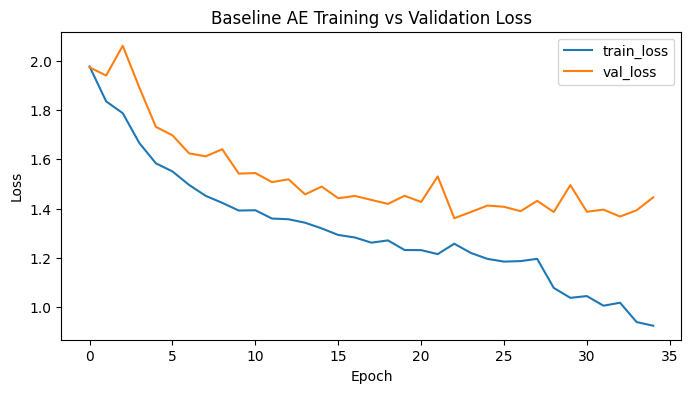

In [8]:
# OPTIONAL LOSS CURVE
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline AE Training vs Validation Loss")
plt.legend()
plt.show()

In [9]:
def topk_score(x_true, x_pred, k):
    err = (x_true - x_pred) ** 2
    flat = err.reshape(len(err), -1)
    k = min(k, flat.shape[1])
    part = np.partition(flat, -k, axis=1)[:, -k:]
    return np.mean(part, axis=1)

In [10]:
# COMPUTE THRESHOLD
model.eval()
train_preds = []

with torch.no_grad():
    for (xb,) in train_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        train_preds.append(pred)

X_tr_pred = np.concatenate(train_preds, axis=0)
train_scores = topk_score(X_trs, X_tr_pred, TOPK)

THRESH = float(np.percentile(train_scores, 95))
baseline_meta = {
    "topk": int(TOPK),
    "threshold": THRESH,
    "window_size": int(WINDOW_SIZE),
    "n_features": int(N_FEATURES),
}

joblib.dump(baseline_meta, os.path.join(SAVE_DIR, "baseline_detector_meta.joblib"))

print("Threshold computed ✅")
print("Threshold:", THRESH)
print("Meta:", baseline_meta)

Threshold computed ✅
Threshold: 415.2713623046875
Meta: {'topk': 19, 'threshold': 415.2713623046875, 'window_size': 24, 'n_features': 8}


In [11]:
# SAVE MODEL
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "window_size": WINDOW_SIZE,
        "n_features": N_FEATURES,
        "units": 64,
        "latent": 64,
    },
    os.path.join(SAVE_DIR, "baseline_ae_model.pt")
)

print("Saved baseline model ✅")

Saved baseline model ✅
